Dataset Shape: (44510, 25)

Target Class Distribution (Potability):
Potability
0.0    95.603136
1.0     4.396864
Name: proportion, dtype: float64

--- Feature Selection Summary ---
Selected Features : Contaminant Level (ppm), pH Level, Turbidity (NTU), Dissolved Oxygen (mg/L), Nitrate Level (mg/L), Lead Concentration (µg/L), Bacteria Count (CFU/mL)
Dropped Features (Macro/Irrelevant data): Country, Region, Year, Water Source Type, Water Treatment Method, Access to Clean Water (% of Population), Diarrheal Cases per 100,000 people, Cholera Cases per 100,000 people, Typhoid Cases per 100,000 people, Infant Mortality Rate (per 1,000 live births), GDP per Capita (USD), Healthcare Access Index (0-100), Urbanization Rate (%), Sanitation Coverage (% of Population), Rainfall (mm per year), Temperature (°C), Population Density (people per km²)



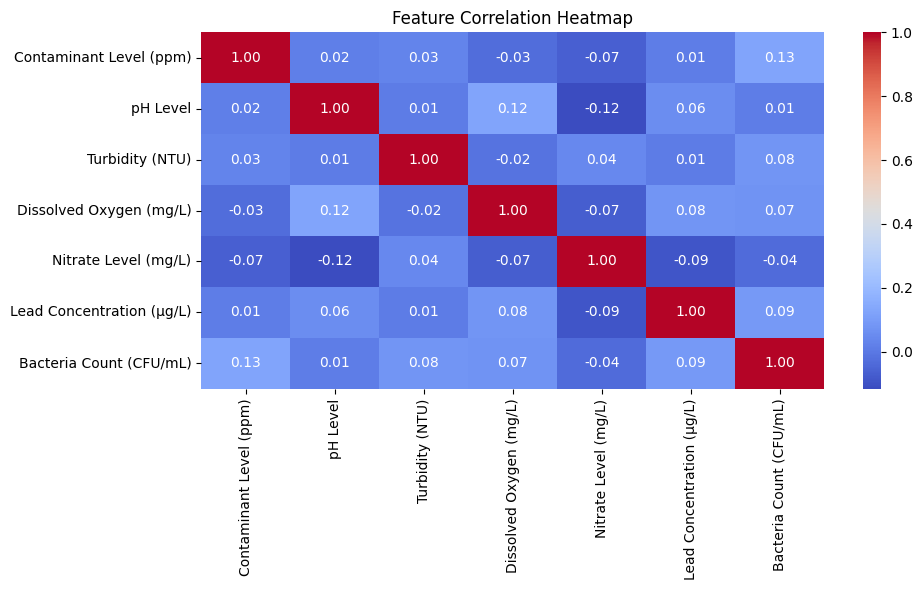


--- Building Neural Network & Hyperparameter Tuning ---
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Neural Network Architecture Found: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (64, 32), 'solver': 'adam'}

--- Model Evaluation ---
Accuracy:  99.84%
Precision: 0.9748
Recall:    0.9898
F1-Score:  0.9822
ROC-AUC:   0.9994


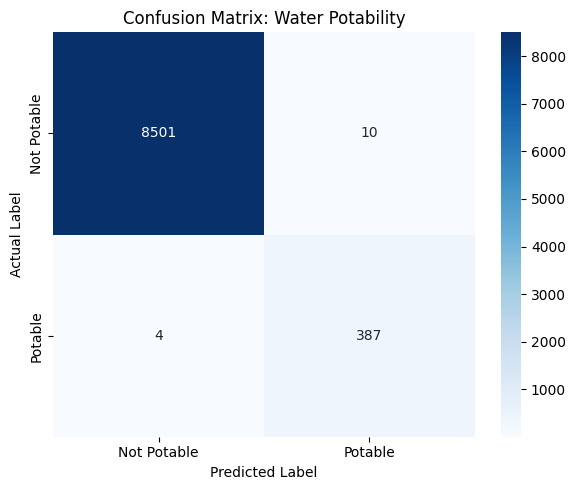

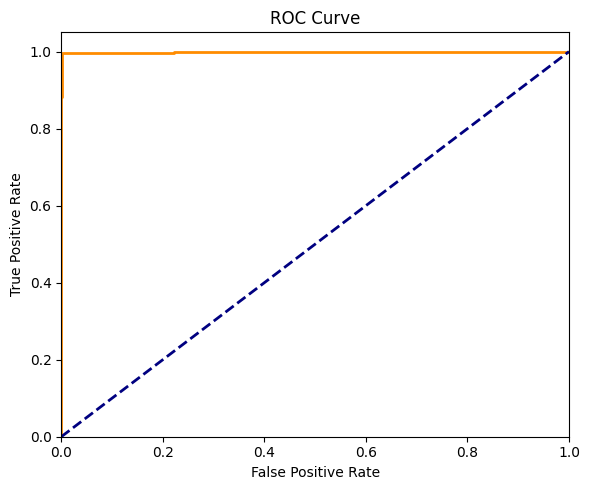

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)


# 1. Exploratory Data Analysis (EDA)
# Load the dataset
df = pd.read_csv('Smart_health_prediction_dataset_1.csv')

# Basic Info
print("Dataset Shape:", df.shape)
print("\nTarget Class Distribution (Potability):")
print(df['Potability'].value_counts(normalize=True) * 100)

# 2. Data Cleaning & Preprocessing
# Fix the encoding issue with the Lead Concentration column name
df.rename(columns={'Lead Concentration (ТЕg/L)': 'Lead Concentration (µg/L)'}, inplace=True)

# Drop rows with missing values in critical sensor columns
critical_cols = [
    'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
    'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
    'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)', 'Potability'
]
df = df.dropna(subset=critical_cols)

# 3. Feature Engineering & Selection
# Remove irrelevant features (like GDP, Year) and keep only IoT Sensor Data
selected_features = [
    'Contaminant Level (ppm)', 'pH Level', 'Turbidity (NTU)',
    'Dissolved Oxygen (mg/L)', 'Nitrate Level (mg/L)',
    'Lead Concentration (µg/L)', 'Bacteria Count (CFU/mL)'
]

# Dynamically find what is being dropped (everything else except our target 'Potability')
dropped_features = [col for col in df.columns if col not in selected_features and col != 'Potability']

# Apply the selection
X = df[selected_features]
y = df['Potability']

# Print the summary
print("\n--- Feature Selection Summary ---")
print(f"Selected Features : {', '.join(selected_features)}")
print(f"Dropped Features (Macro/Irrelevant data): {', '.join(dropped_features)}\n")

# EDA Visualization: Correlation Heatmap of Selected Features
plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (Mean=0, Variance=1) - Critical for Neural Networks
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5  Model Building, Training & Hyperparameter Tuning
print("\n--- Building Neural Network & Hyperparameter Tuning ---")
# Define the base Artificial Neural Network (Multilayer Perceptron)
base_ann = MLPClassifier(random_state=42, max_iter=200)

# Define the architecture parameters to test
# Trying different layers, neurons, and activation functions
param_grid = {
    'hidden_layer_sizes': [(16, 8), (32, 16, 8), (64, 32)], # Testing different depths/neurons
    'activation': ['relu', 'tanh'],                         # Testing activation functions
    'solver': ['adam'],                                     # Adam optimizer
    'alpha': [0.0001, 0.001],                               # L2 penalty (regularization)
}

# Use GridSearchCV to find the absolute best combination of hyperparameters
grid_search = GridSearchCV(base_ann, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

# Extract the best model
best_ann = grid_search.best_estimator_
print(f"Best Neural Network Architecture Found: {grid_search.best_params_}")

# 6. Model Evaluation
print("\n--- Model Evaluation ---")
y_pred = best_ann.predict(X_test_scaled)
y_prob = best_ann.predict_proba(X_test_scaled)[:, 1] # Get probabilities for ROC-AUC

# Calculate Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# 7. Results & Visualization
# Confusion metrics
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Potable', 'Potable'], yticklabels=['Not Potable', 'Potable'])
plt.title('Confusion Matrix: Water Potability')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# ROC Curve Visualization
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.tight_layout()
plt.show()

In [ ]:
# Check for Overfitting
train_accuracy = accuracy_score(y_train, best_ann.predict(X_train_scaled))
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy * 100:.2f}%")


Training Accuracy: 99.90%
Testing Accuracy:  99.86%


In [ ]:
import numpy as np

# EARLY WARNING SYSTEM SIMULATION

def process_live_sensor_data(contaminant, ph, turbidity, do, nitrate, lead, bacteria):
    """ Simulates receiving live data from IoT sensors, evaluating the risk,
    and generating an early warning alert if necessary. """

    print("\n[RECEIVING LIVE SENSOR DATA...]")

    # 1. Format the incoming data into a 2D array (matching training format)
    # Order: Contaminant, pH, Turbidity, DO, Nitrate, Lead, Bacteria
    live_data = np.array([[contaminant, ph, turbidity, do, nitrate, lead, bacteria]])

    # 2. Preprocess: Scale the live data using the EXACT SAME scaler from training
    live_data_scaled = scaler.transform(live_data)

    # 3. AI Prediction Model: Predict Potability (0 or 1)
    prediction = best_ann.predict(live_data_scaled)[0]

    # 4. Risk Evaluation & Early Warning Generation
    if prediction == 0: # 0 means NOT POTABLE
        print("URGENT: WATER QUALITY ALERT TRIGGERED")
        print("STATUS: NOT POTABLE - HIGH RISK OF WATERBORNE DISEASE")

        # Determine specific risks based on the readings
        risks = []
        if bacteria > 500: risks.append("High Bacterial Contamination (Cholera/Typhoid Risk)")
        if lead > 10: risks.append("Toxic Lead Levels Detected")
        if ph < 6.5 or ph > 8.5: risks.append("Dangerous pH Imbalance")

        print(f"IDENTIFIED RISKS: {', '.join(risks)}")
        print("\n[SYSTEM ACTION]: Sending automated SMS alerts to local clinics and community apps...")
        # In real life, this is where you'd trigger an API like Twilio to send an SMS

    else: # 1 means POTABLE
        print("SYSTEM STATUS: NORMAL")
        print("STATUS: POTABLE - WATER IS SAFE FOR CONSUMPTION")
        print("[SYSTEM ACTION]: Updating community dashboard with safe metrics.")

# --- TEST SCENARIO 1: Safe Water ---
# Processing clean water parameters
process_live_sensor_data(contaminant=2.0, ph=7.2, turbidity=1.5, do=6.0, nitrate=10.0, lead=2.0, bacteria=100)

# --- TEST SCENARIO 2: Dangerous Water (e.g., Post-Flood Contamination) ---
# Processing water with high bacteria and lead
process_live_sensor_data(contaminant=8.0, ph=6.0, turbidity=6.5, do=2.0, nitrate=60.0, lead=15.0, bacteria=850)


[RECEIVING LIVE SENSOR DATA...]
SYSTEM STATUS: NORMAL
STATUS: POTABLE - WATER IS SAFE FOR CONSUMPTION
[SYSTEM ACTION]: Updating community dashboard with safe metrics.

[RECEIVING LIVE SENSOR DATA...]
URGENT: WATER QUALITY ALERT TRIGGERED
STATUS: NOT POTABLE - HIGH RISK OF WATERBORNE DISEASE
IDENTIFIED RISKS: High Bacterial Contamination (Cholera/Typhoid Risk), Toxic Lead Levels Detected, Dangerous pH Imbalance

[SYSTEM ACTION]: Sending automated SMS alerts to local clinics and community apps...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import joblib

# Export the trained model and the scaler
joblib.dump(best_ann, 'water_potability_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved successfully!")

Model and scaler saved successfully!
